In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, RocCurveDisplay
)

sns.set(style="whitegrid")
%matplotlib inline

In [ ]:
data_path = "breast+cancer+wisconsin+diagnostic/wdbc.data"
feature_names = [
    "mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness",
    "mean compactness", "mean concavity", "mean concave points", "mean symmetry",
    "mean fractal dimension", "radius error", "texture error", "perimeter error",
    "area error", "smoothness error", "compactness error", "concavity error",
    "concave points error", "symmetry error", "fractal dimension error",
    "worst radius", "worst texture", "worst perimeter", "worst area", "worst smoothness",
    "worst compactness", "worst concavity", "worst concave points", "worst symmetry",
    "worst fractal dimension"
]

raw_df = pd.read_csv(data_path, header=None, names=["id", "diagnosis"] + feature_names)
df = raw_df.drop(columns="id")
df["target"] = df["diagnosis"].map({"M": 0, "B": 1})
df = df.drop(columns="diagnosis")

print("Shape:", df.shape)
df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [4]:
# Missing values
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")

# Duplicates
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_count}")
df = df.drop_duplicates()   # handle duplicates if any

# Outlier detection using IQR method
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

outlier_summary = df.drop(columns='target').apply(count_outliers_iqr).sort_values(ascending=False)
print("\nTop 10 features by outlier count (IQR method):")
print(outlier_summary.head(10))

# NOTE: moderate outliers are kept since medical measurements can be legitimately
# extreme (e.g., large tumors); we flag them but don't remove them.

Missing values per column:
 0 total missing values

Duplicate rows: 0

Top 10 features by outlier count (IQR method):
area error                 65
radius error               38
perimeter error            38
worst area                 35
smoothness error           30
fractal dimension error    28
compactness error          28
symmetry error             27
mean area                  25
worst fractal dimension    24
dtype: int64


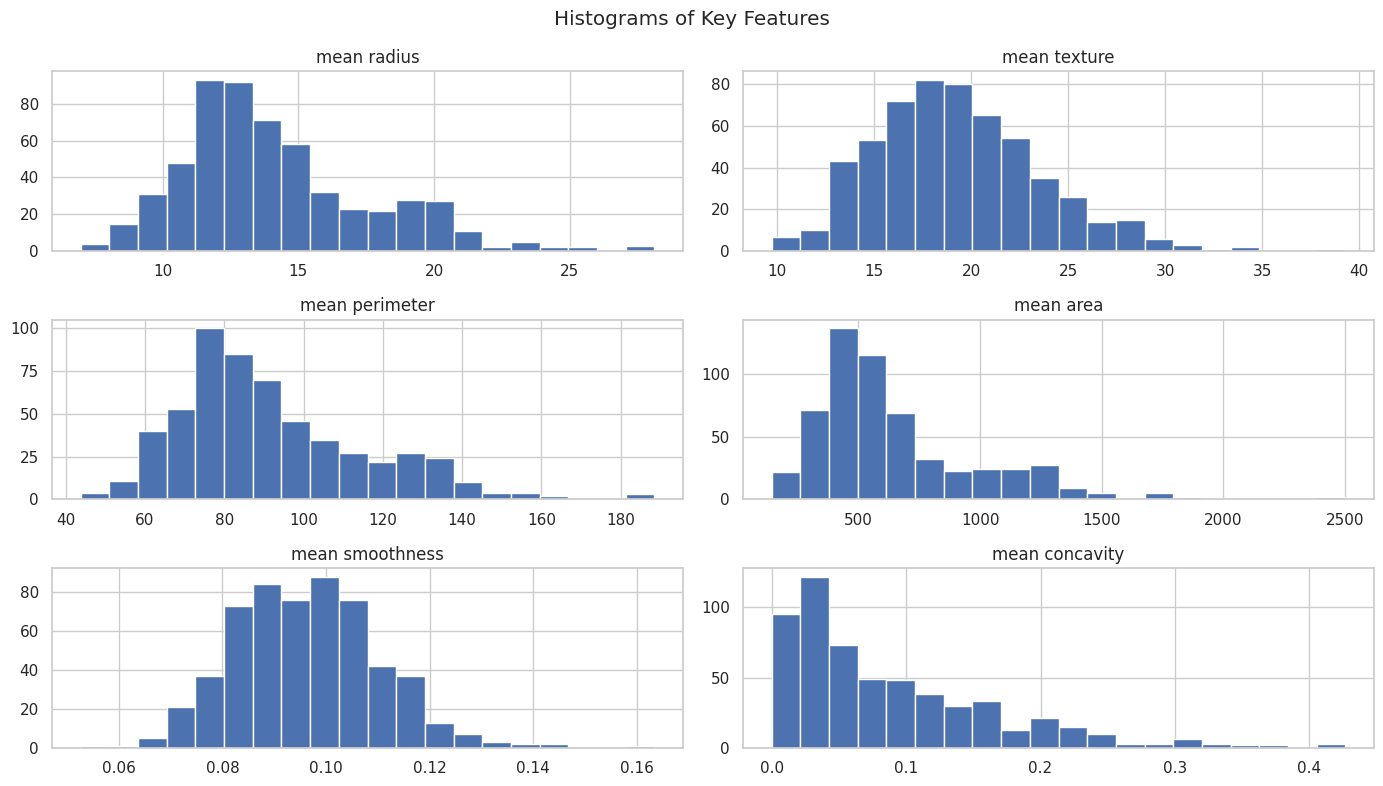

In [5]:
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                 'mean smoothness', 'mean concavity']

df[key_features].hist(bins=20, figsize=(14, 8))
plt.suptitle("Histograms of Key Features")
plt.tight_layout()
plt.show()

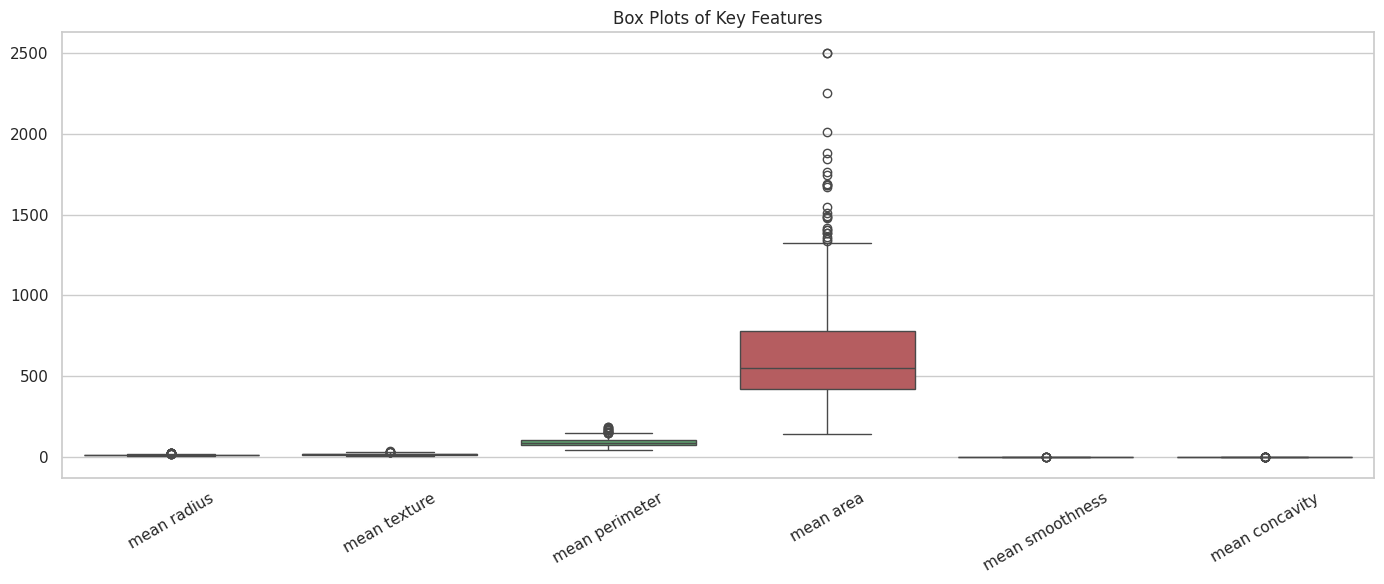

In [6]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[key_features])
plt.xticks(rotation=30)
plt.title("Box Plots of Key Features")
plt.tight_layout()
plt.show()

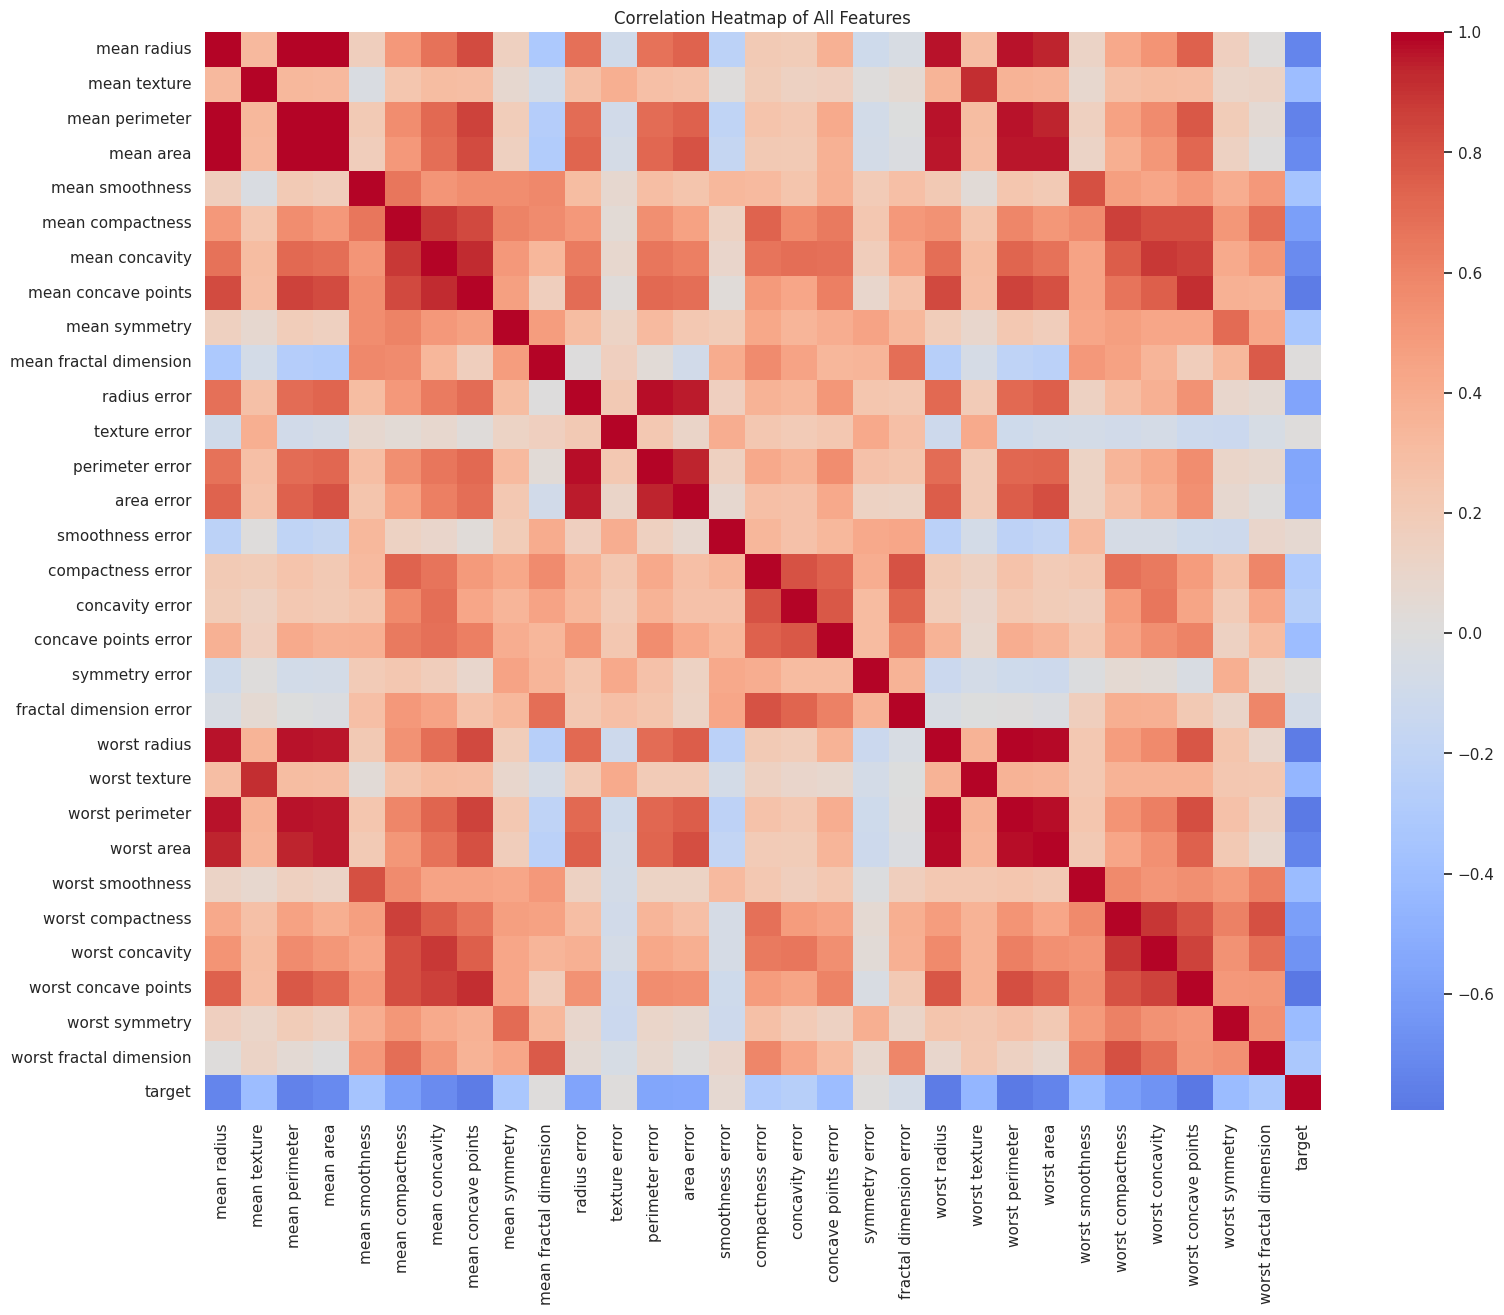

In [7]:
plt.figure(figsize=(18, 14))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, center=0)
plt.title("Correlation Heatmap of All Features")
plt.show()

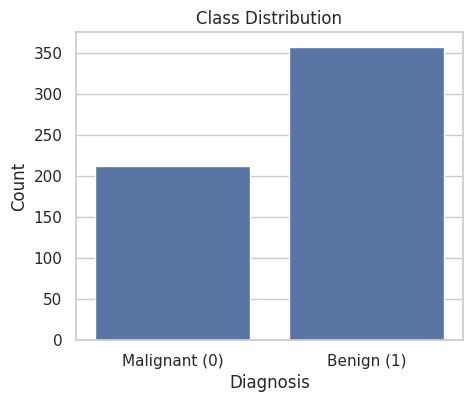

target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(5, 4))
sns.countplot(x='target', data=df)
plt.xticks([0, 1], ['Malignant (0)', 'Benign (1)'])
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

print(df['target'].value_counts(normalize=True) * 100)

In [9]:
df['Outcome'] = df['target'].map({0: 1, 1: 0})   # Outcome = 1 means malignant
df = df.drop(columns='target')

X = df.drop(columns='Outcome')
y = df['Outcome']

print(y.value_counts())

Outcome
0    357
1    212
Name: count, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

Train shape: (455, 30)  Test shape: (114, 30)

Train class balance:
 Outcome
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Test class balance:
 Outcome
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled.describe().T[['mean', 'std']].head()

,mean,std
mean radius,-1.737316e-16,1.001101
mean texture,3.904081e-16,1.001101
mean perimeter,4.704418e-16,1.001101
mean area,-1.171224e-16,1.001101
mean smoothness,7.242070e-16,1.001101


In [12]:
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [13]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9649


In [14]:
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



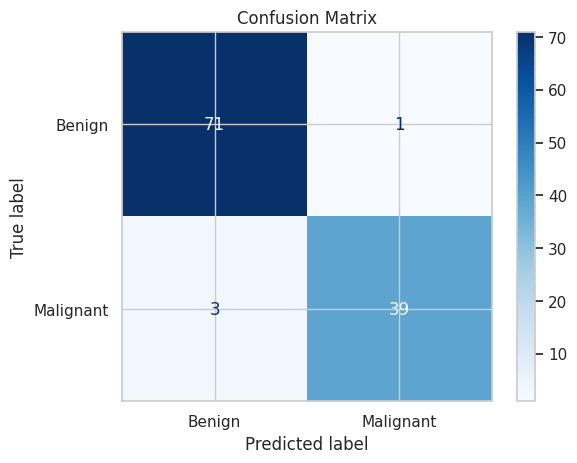

In [15]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

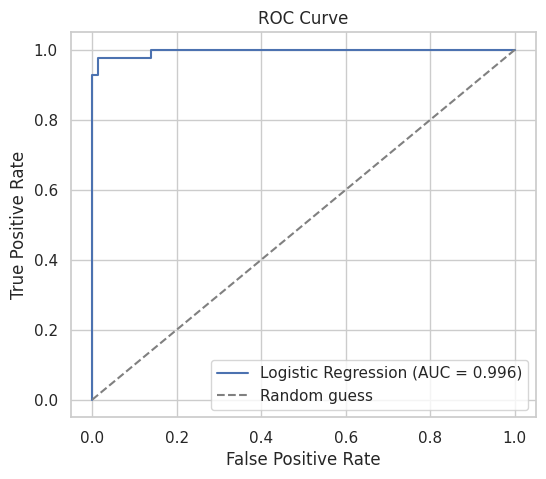

AUC Score: 0.9960


In [16]:
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"AUC Score: {auc:.4f}")